In [1]:
# Check your Python version
from platform import python_version
python_version()

#!python -V
# pandas package needs to be added to the requirements.txt 's file 
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Character Limits: A Technical Case Study of Reverse-Engineering and  Fan-Translating Japanese Visual Novels on the Game Boy Advance

 ### Ian F.V.G. Hunter [![orcid](https://orcid.org/sites/default/files/images/orcid_16x16.png)](https://orcid.org/0000-0003-3408-8138) 
Unaffiliated

[![cc-by](https://licensebuttons.net/l/by/4.0/88x31.png)](https://creativecommons.org/licenses/by/4.0/) 
©Ian F.V.G. Hunter. Published by De Gruyter in cooperation with the University of Luxembourg Centre for Contemporary and Digital History. This is an Open Access article distributed under the terms of the [Creative Commons Attribution License CC-BY](https://creativecommons.org/licenses/by/4.0/)


Reverse Engineering, Translation, Game Boy Advance, GBA, ROM Hacking, Visual Novels, Digital Preservation, Fanslation, Retro Gaming, Fanslation, Fan Translation

Throughout video game history, many titles have only been released regionally, whether for cultural, financial or other reasons. This paper examines the niche field of hobbyist or otherwise unofficial translation and repackaging of these games, making them accessible to audiences previously unable to engage with the media. By providing a technical case study of such a game's localization using reverse engineering techniques, this paper explores a side of the field that has seen little academic attention, discusses the complexities associated with the activity and highlights the crucial role of such grassroots initiatives in the preservation of digital culture.

## Introduction

Nintendo's Game Boy Advance (GBA) was launched in 2001 and ceased production in 2010 <cite id="bc3sn"><a href="#zotero%7C23690838%2FJM7QDKED">(Nintendo Co., Ltd., 2024)</a></cite>. Software sales continued for 2 more years before becoming a negligible amount in Nintendo's sales <cite id="rbwqm"><a href="#zotero%7C23690838%2FPU8S75C2">(Nintendo Co., 2015)</a></cite>. Since then, there have been three further generations of game consoles, which game development companies have moved onto, with significantly more processing and graphics capabilities.

However, a small niche of development continues on the GBA. A handful of indie developers have released original games for the console well after 2012  --- e.g., Goodboy Galaxy was funded on Kickstarter in 2025, promising a GBA release <cite id="p0uej"><a href="#zotero%7C23690838%2FIJCI3JAI">(Rik, 2021)</a></cite>. There is also a community of self-titled "ROM Hackers" (ROM here referring to the physical cartridges the games are stored on) who modify existing games to adapt, extend, and experiment with. 

A sub-group of these "ROM Hackers" are fan translators – or as they are more commonly known in the sphere "fanslators". Many GBA titles were released in only one language or a limited set of languages and never localized to other regions, excluding potential players. In [Table 1](table-gba-languages), we show the distribution of language support in the GBA games on the popular IGDB website. As can be seen, there is a sharp drop in non-English support, particularly outside Japanese and major European languages. With the discontinuation of the GBA ecosystem, most games are now unlikely to see an official new language release. By the fan translators unofficially translating these games, these games can reach a new audience. Despite the unlikelihood of official releases, GBA games are still under copyright in most jurisdictions, making much of the hobbyist work be of questionable legality. Initial legal cases such as the Nintendo vs GameGenie <cite id="eaul8"><a href="#zotero%7C23690838%2F4H2IPDGD">(U.S. Court of Appeals for the Ninth Circuit, 1992)</a></cite> "cheat cartridge" case have shown that the act of reverse engineering and modification of console code is itself not inherently illegal. Many other aspects of the law have not been tested in court, as companies typically have focussed on activities that can be seen as a percieved commercial conflict (e.g. creating seperate 'level' packs for an active console was deemed an illegal derivative in the MicroStar vs FormGen case <cite id="0zdfq"><a href="#zotero%7C23690838%2FS2Q4IPIQ">(U.S. Court of Appeals for the Ninth Circuit, 1992a)</a></cite>) and companies tend to prefer issuing takedown notices over costly legal battles (Such as the takedown request of the Metroid II remake project <cite id="zbimi"><a href="#zotero%7C23690838%2FU6DWCJ4M">(Machkovech, 2016)</a></cite>).

Despite the focus on protecting active commercial interests, even during the GBA's lifetime, several bootleg copies of popular games have been sold with unofficial (and often questionable, as seen in [Figure 1](#figure-bootleg)) translations. Unlike the majority of the ROM-hacking community, which generally operates on a non-profit basis, these physical counterfeits represented a direct trademark and copyright violation that Nintendo actively pursued through coordinated seizures with government organizations. The correspondence between Nintendo and the International Intellectual Property Alliance (IIPA) <cite id="47nko"><a href="#zotero%7C23690838%2FV4EQ2TW8">(Nintendo of America Inc., 2008)</a></cite> goes into great detail about the high volume of counterfeit cartridges, difficulties with differences in IP law and enforcement of such in other countries, and a set of recommended trade monitoring actions. These cartridges often included non-modified games that were illegally manufactured.

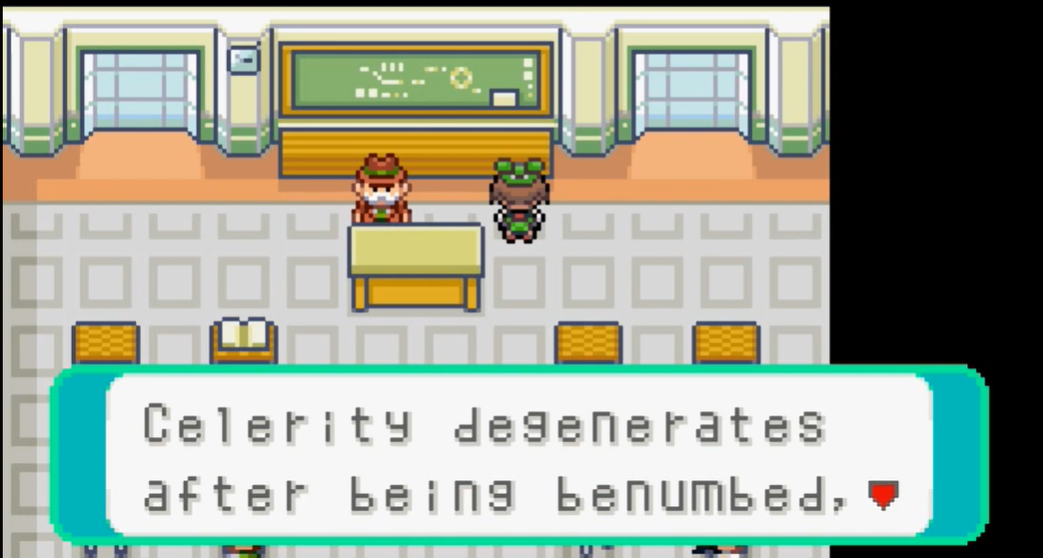

In [2]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Screenshot from a bootleg copy of Pokémon Emerald (A possible correct translation might read \"The 'Paralyze' effect reduces a Pokémon's speed\""
            ]
        }
    }
}
display(Image("media/bootleg.png"), metadata=metadata)

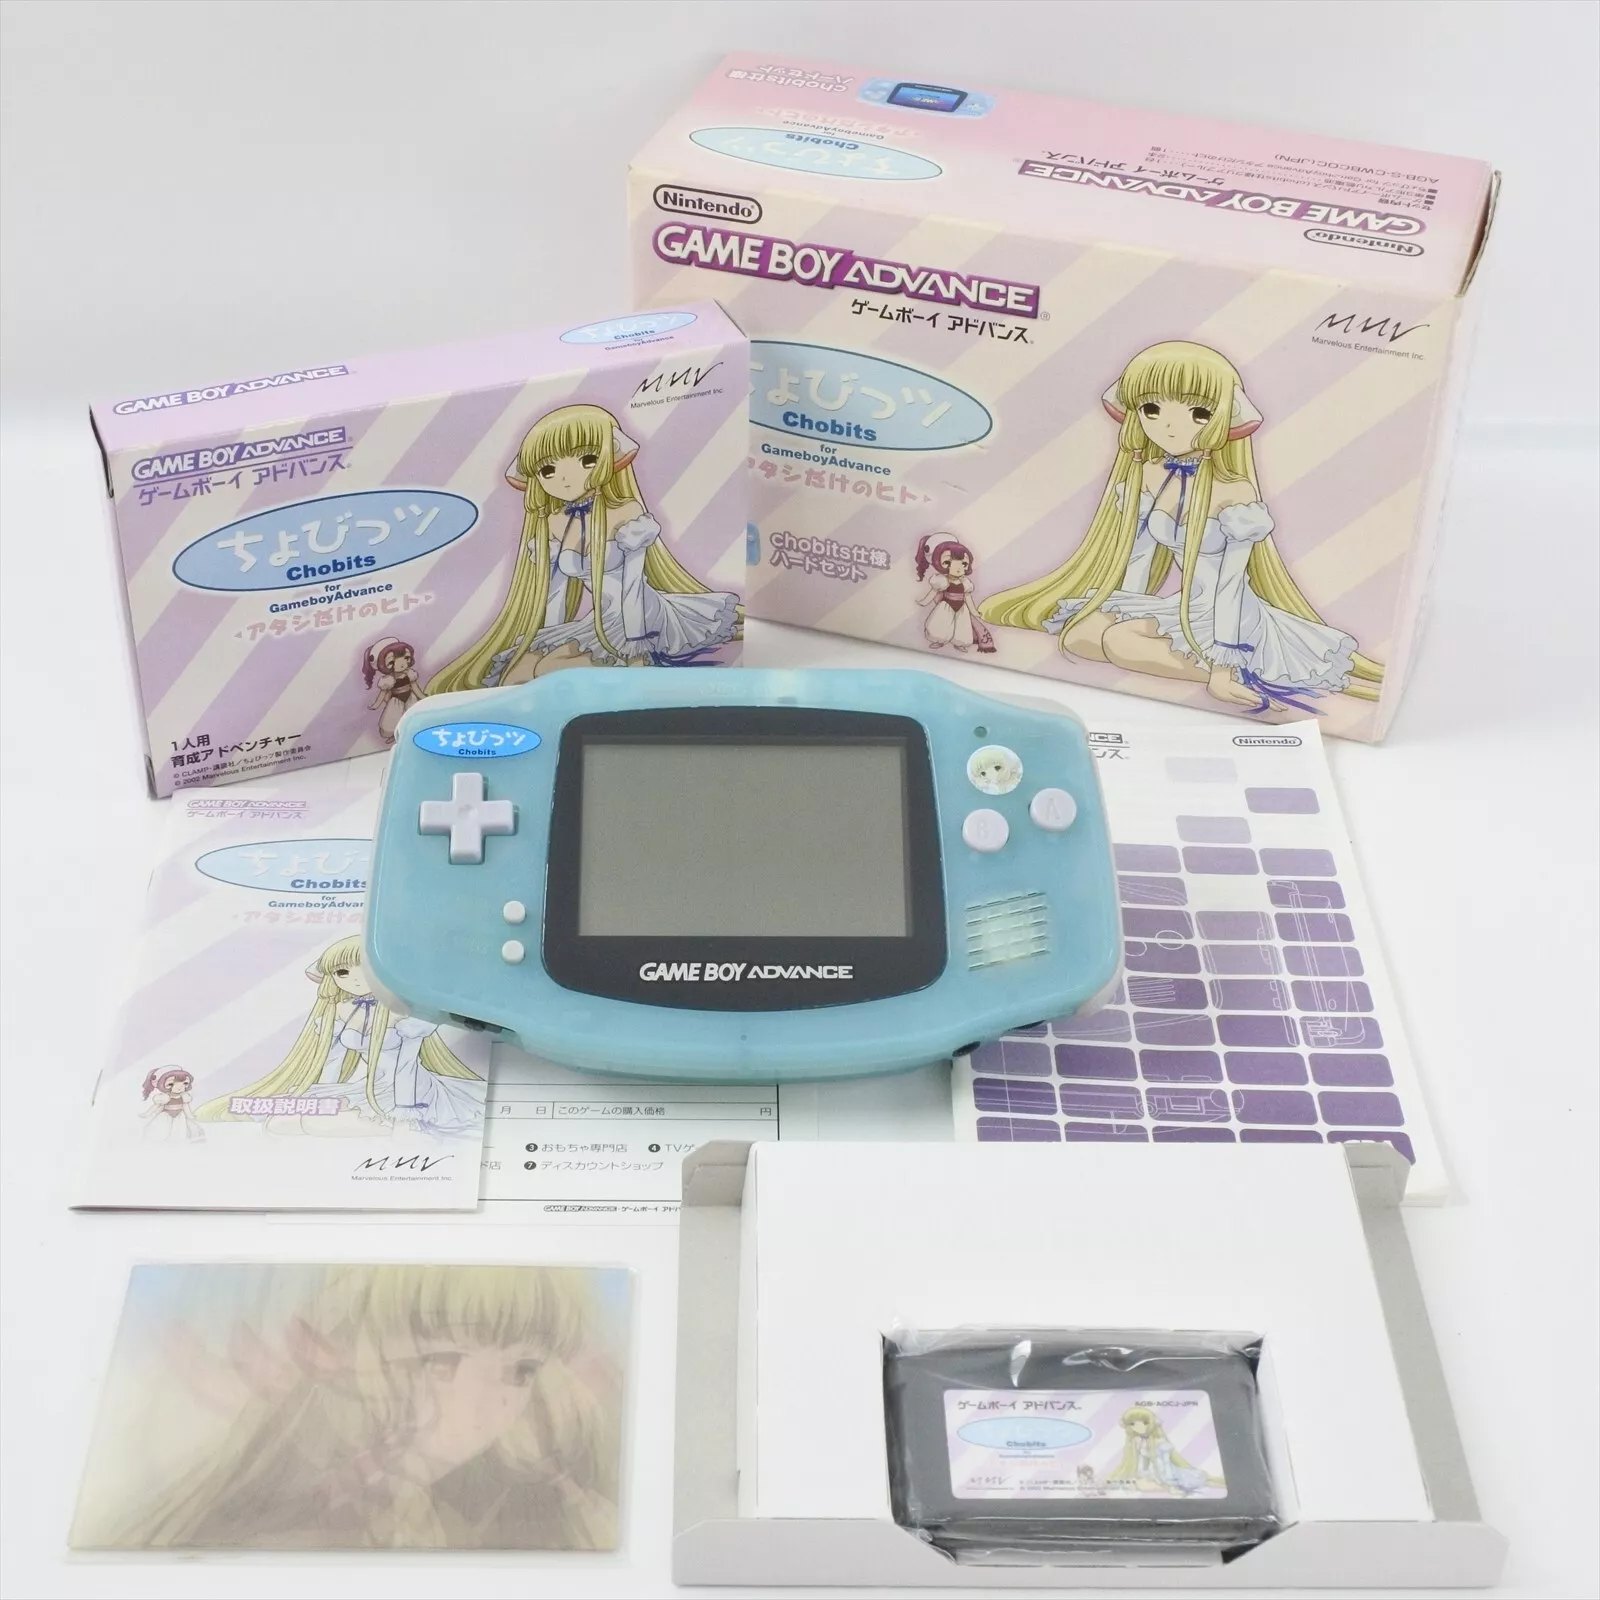

In [3]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "The Chobits GBA game and associated limited edition console."
            ]
        }
    }
}
# Image reproduced with express permission from hit-japan (eBay).
display(Image("media/gba-package.png"), metadata=metadata)

Much of the existing academic literature that discusses the practise of ROM Hacking and/or fanslation is often framed around this legal context, as well as cultural and societal aspects of the practise (see, for example, <cite id="3gnbi"><a href="#zotero%7C23690838%2FNNZKYJRK">(Barnabé, 2018)</a></cite> and <cite id="ad9g5"><a href="#zotero%7C23690838%2FPT72WSJN">(Kirtz, 2018)</a></cite>). <cite id="vgofj"><a href="#zotero%7C23690838%2F7PTYDRD9">(Sánchez, 2009)</a></cite> provides a high-level overview of some techniques used by fan translators, but in this paper, we investigate at a deeper level through a practical case study of prototyping a reverse-engineered translation of a game, and review the challenges we faced. We review how the practice could be modernized and accellerated taking into account the last 20 years of innovation in computational advances.

While we will refer to other games, this research has been performed primarily on the Japanese visual novel game "ちょびっツ for GameboyAdvance -アタシだけのヒト–", or in roman characters – "Chobits: Atashi Dake no Hito" (Shortened to just "Chobits" for convenience for the rest of this paper). The methods in this work are independent of the actual title used.

### Background Information

The choice of *Chobits* for the case study within this paper is somewhat purposeful as it reflects both cultural and technical aspects of video game fan translation. First published as a manga in Japan in 2001 by Kodansha, *Chobits* was later translated and released in English by Tokyopop, which notes the original publication date <cite id="14wnk"><a href="#zotero%7C23690838%2FLCRQJ5I6">(CLAMP, 2002)</a></cite>, it was subsequently adapted into a 26-episode animated television series as well as three video games (the Game Boy Advance title examined in this paper, a PC game, and another on the Sony PlayStation 2) (<cite id="vecpj"><a href="#zotero%7C23690838%2FMGILIBEV">(<i>Chobits: Atashi Dake no Hito</i>, 2002)</a></cite>, <cite id="h5reu"><a href="#zotero%7C23690838%2FM44CMMKJ">(<i>Chobits: Chii Dake No Hito</i>, 2003)</a></cite>). The GBA game was released with a limited-edition GBA device (Figure \ref{fig:chobitspackage}). The game achieved commercial success in Japan and maintains cultural relevance, with the series continuing to be referenced in later media.

The series also had significant international reach --- The series has been licensed in North America, Taiwan, the Netherlands, Germany, Russia, and has been broadcast on Korean, Spanish, Portugese and Polish television networks. Recently, 20th anniversary editions of the manga were produced in English. Such widespread appeal suggests that an official translation of the game would have likely found at least a niche international audience.

As a work derived from a manga title, the fanslation of *Chobits* mirrors the efforts of fanslators in the subculture for decades, well before the GBA was even released. Anime and manga have a strong fan culture of sharing inaccessible media in the absence of licensing or localization companies. Tremblay argues that these sorts of efforts have created stronger interest in media and the genre as a whole, along with strengthened consumer investment into future products, much like how the Japanese doujinshi (unauthorized fan comics) are actively encouraged by their media's owners as it is seen as symbiotic rather than competitive \ref{FiT}. Indeed, several companies in media distribution have been created from systems such as these. A well-known example is Crunchyroll, now the largest dedicated anime streaming service, which was originally a fan-subtitle aggregation website before transitioning into a licensed platform <cite id="83jzg"><a href="#zotero%7C23690838%2FLMHMAPSC">(Loo, 2008)</a></cite>. Another notable example is Manga Rock, a frontend for several illegal manga-hosting websites which transitioned into an official platform for manga, manwha and webtoons <cite id="nja2p"><a href="#zotero%7C23690838%2FNEKBFI45">(Mateo, 2020)</a></cite>. 

As noted in the [Introduction](#introduction), existing academic work is predominantly concerned with these interesting legal and cultural scenarios, rather than the technical process of translation. As a visual novel, *Chobits* is a title with a lot of textual and visual content, which can be difficult to fit within the limited confines of the GBA device. Its translation is also crucial to the accessibility of the media, unlike other games, which one can enjoy without translation. \todo{write that better - mechanic-based games or something} Unlike anime or manga translation, which requires translation skills and some level of competency with image editing and subtitling software, translating this game perfectly would require an advanced programming skillset with an ability to reverse engineer and understand embedded devices. This high barrier to entry has historically limited the number of complete fanslations released each year. In Figure \ref{fig:releases}, a timeline of final releases of GBA games is shown, gathered from the romhacking.net community. The substantial increase in releases from 2019 to 2022 coincides with COVID-19 movement restrictions, which likely contributed to increased participation in home-based hobbies.

| Language               | Total | Percentage (%) |
|------------------------|-------|----------------|
| English                | 710   | 76.84          |
| Japanese               | 326   | 35.28          |
| French                 | 97    | 10.5           |
| German                 | 97    | 10.5           |
| Spanish (Spain)        | 83    | 8.98           |
| Italian                | 80    | 8.66           |
| Dutch                  | 43    | 4.65           |
| Danish                 | 15    | 1.62           |
| Chinese (Simplified)   | 14    | 1.52           |
| Swedish                | 10    | 1.08           |
| Norwegian              | 9     | 0.97           |
| Portuguese (Portugal)  | 8     | 0.87           |
| English (UK)           | 7     | 0.76           |
| Finnish                | 6     | 0.65           |
| Portuguese (Brazil)    | 3     | 0.32           |
| Polish                 | 3     | 0.32           |
| Korean                 | 2     | 0.22           |
| Spanish (Mexico)       | 2     | 0.22           |
| Arabic                 | 1     | 0.11           |
| Chinese (Traditional)  | 1     | 0.11           |

The distribution of language data in games gathered from the IGDB website should be considered with additional context. As a community-maintained resource, the completeness and accuracy of data entries vary. More popular titles tend to be more comprehensively catalogued. Furthermore, the English language interface may introduce biases in the quality and quantity of contributions to English or English-translated titles, over other languages. It is also prone to contributor error. Consequently, this data should be treated as an approximate representation of language support on the GBA, rather than a definitive or objective distribution.

Loading CSVs...
Normalizing & Aggregating...
Visualizing...


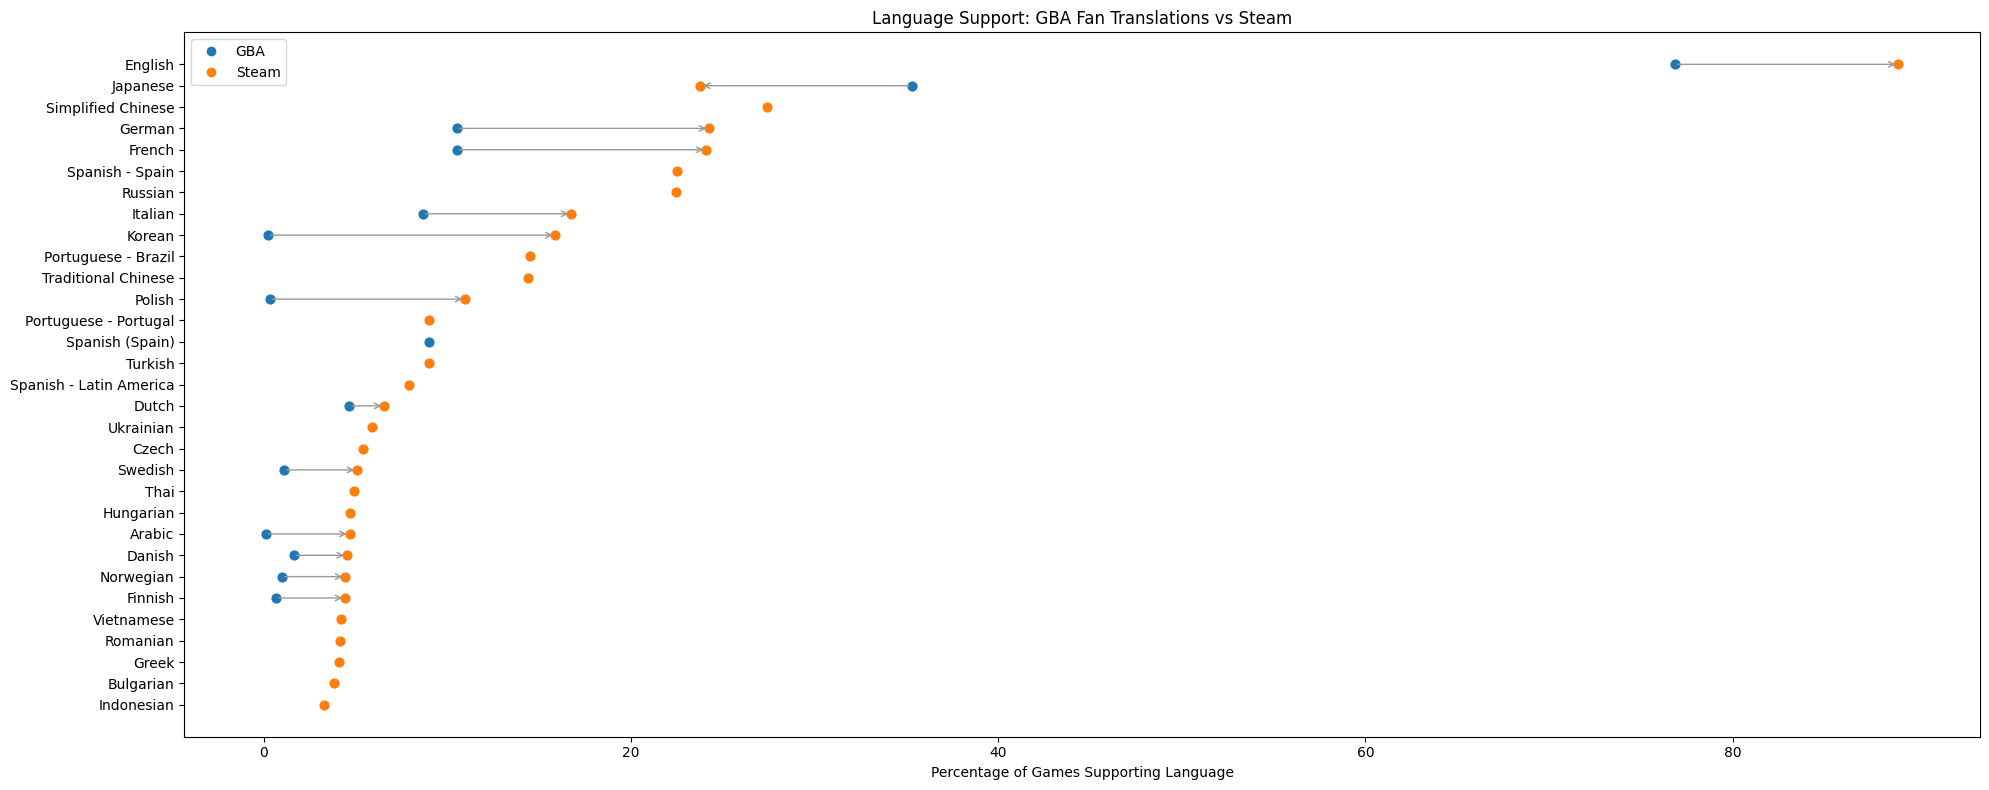

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import html

print("Loading CSVs...")

# Load GBA CSV
df_gba = pd.read_csv("https://raw.githubusercontent.com/ianfhunter/gba-fanslation-sample/refs/heads/main/gba_language_distribution.csv")

# Load Steam CSV (cleaned JSON converted to CSV)
df_steam = pd.read_csv("https://raw.githubusercontent.com/ianfhunter/gba-fanslation-sample/refs/heads/main/steam_games_clean.csv")

print("Normalizing & Aggregating...")

# --- Normalize column names ---
df_gba.columns = df_gba.columns.str.strip().str.lower().str.replace(" ", "_")
df_steam.columns = df_steam.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename percentage columns
df_gba = df_gba.rename(columns={"percentage_(%)": "fan_pct"})
df_steam = df_steam.rename(columns={"steam_pct": "steam_pct"})
df_steam = df_steam.rename(columns={"supported_languages": "language"})

# Steam lists multiple languages in one cell (e.g. "English, Russian"); count each language per game
steam_expanded = df_steam.assign(
    language=df_steam["language"].fillna("").astype(str).str.split(",")
).explode("language", ignore_index=True)
steam_expanded["language"] = steam_expanded["language"].str.strip()
steam_expanded = steam_expanded[steam_expanded["language"].ne("")]

# --- Aggregate Steam data by language ---
steam_lang_pct = (
    steam_expanded.groupby("language")
    .size()
    .reset_index(name="steam_count")
)

total_steam_games = len(df_steam)
steam_lang_pct["steam_pct"] = steam_lang_pct["steam_count"] / total_steam_games * 100
steam_lang_pct = steam_lang_pct[["language", "steam_pct"]]

# --- Merge GBA and Steam ---
merged = pd.merge(df_gba, steam_lang_pct, on="language", how="outer")

# --- Sort by max value for readability ---
merged["sort_val"] = merged[["fan_pct", "steam_pct"]].max(axis=1)
merged = merged.sort_values("sort_val")

# Filtering out very low percentage languages
minimal_threshold = 2
merged = merged[(merged["fan_pct"].notna()) | (merged["steam_pct"].notna())]
merged = merged[
    (merged["fan_pct"] > minimal_threshold) | (merged["steam_pct"] > minimal_threshold)
]

print("Visualizing...")

# --- Colors ---
gba_color = "#1f77b4"
steam_color = "#ff7f0e"
line_color = "#999999"

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 8))
y_pos = np.arange(len(merged))

for i, row in enumerate(merged.itertuples(index=False)):
    x0 = row.fan_pct
    x1 = row.steam_pct

    # Arrow between both points when both are finite percentages
    if pd.notna(x0) and pd.notna(x1) and x0 != x1:
        ax.annotate(
            "",
            xy=(x1, i),
            xytext=(x0, i),
            arrowprops=dict(arrowstyle="->", color=line_color, lw=1),
        )

    # Dots where we have a value
    if pd.notna(x0):
        ax.scatter(x0, i, color=gba_color, s=40)
    if pd.notna(x1):
        ax.scatter(x1, i, color=steam_color, s=40)

# --- Labels ---
ax.set_yticks(y_pos)
ax.set_yticklabels(merged["language"])
ax.set_xlabel("Percentage of Games Supporting Language")
ax.set_title("Language Support: GBA Fan Translations vs Steam")

# --- Ensure lone points are visible ---
all_values = list(merged["fan_pct"].dropna()) + list(merged["steam_pct"].dropna())

xmin = min(all_values) if all_values else 0
xmax = max(all_values) if all_values else 1
padding = (xmax - xmin) * 0.05 if xmax != xmin else 1
ax.set_xlim(xmin - padding, xmax + padding)

# --- Legend ---
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='GBA',
           markerfacecolor=gba_color, markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Steam',
           markerfacecolor=steam_color, markersize=8)
]

ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

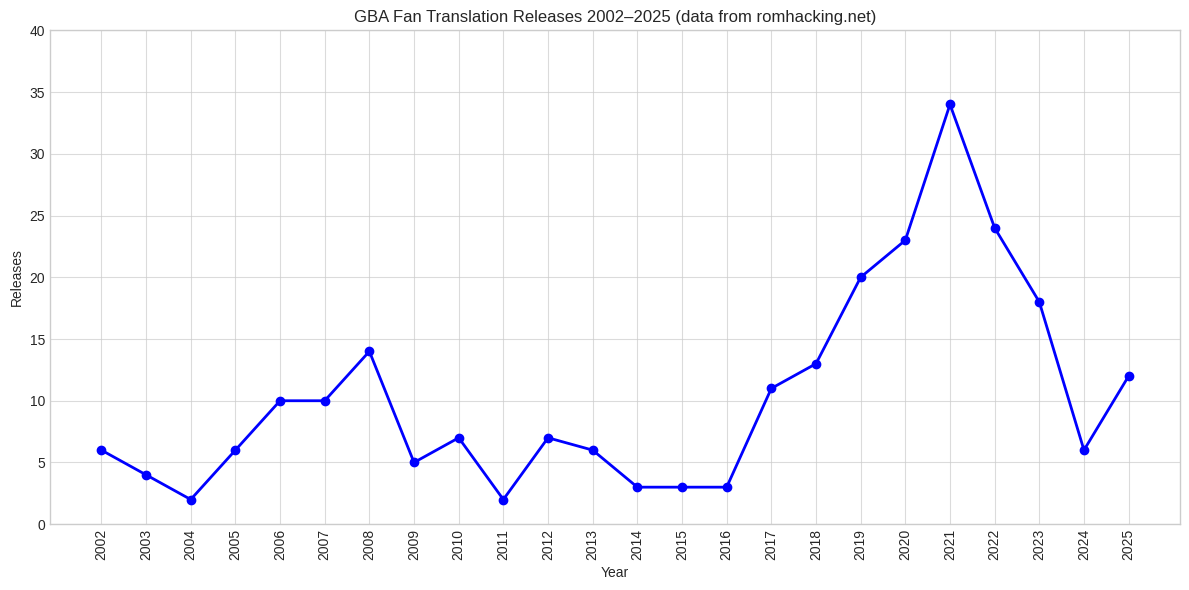

In [5]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
# 1. Prepare the data
data = [
    (2002,6), (2003,4), (2004,2), (2005,6), (2006,10), (2007,10),
    (2008,14), (2009,5), (2010,7), (2011,2), (2012,7), (2013,6),
    (2014,3), (2015,3), (2016,3), (2017,11), (2018,13), (2019,20),
    (2020,23), (2021,34), (2022,24), (2023,18), (2024,6), (2025,12)
]

years, releases = zip(*data)

# 2. Create the plot
plt.figure(figsize=(12, 6))
plt.plot(years, releases, color='blue', marker='o', linewidth=2, markersize=6)

# 3. Apply TikZ-like styling
plt.xlabel('Year')
plt.ylabel('Releases')
plt.title('GBA Fan Translation Releases 2002–2025 (data from romhacking.net)')

# Set axis limits and ticks to match your LaTeX code
plt.ylim(0, 40)
plt.xticks(years, rotation=90)
plt.grid(True, linestyle='-', alpha=0.7)

# 4. Display
plt.tight_layout()
plt.show()

### Game Boy Advance

The choice of *Chobits* for the case study within this paper is somewhat purposeful as it reflects both cultural and technical aspects of video game fan translation. First published as a manga in Japan in 2001 by Kodansha, *Chobits* was later translated and released in English by Tokyopop, which notes the original publication date <cite id="cyw4i"><a href="#zotero%7C23690838%2FLCRQJ5I6">(CLAMP, 2002)</a></cite>), it was subsequently adapted into a 26-episode animated television series as well as three video games (the Game Boy Advance title examined in this paper, a PC game, and another on the Sony PlayStation 2) <cite id="ej67i"><a href="#zotero%7C23690838%2FM44CMMKJ">(<i>Chobits: Chii Dake No Hito</i>, 2003)</a></cite>, <cite id="qp1vw"><a href="#zotero%7C23690838%2FMGILIBEV">(<i>Chobits: Atashi Dake no Hito</i>, 2002)</a></cite>). The GBA game was released with a limited-edition GBA device (Figure \ref{fig:chobitspackage}). The game achieved commercial success in Japan and maintains cultural relevance, with the series continuing to be referenced in later media.

The series also had significant international reach --- The series has been licensed in North America, Taiwan, the Netherlands, Germany, Russia, and has been broadcast on Korean, Spanish, Portugese and Polish television networks. Recently, 20th anniversary editions of the manga were produced in English. Such widespread appeal suggests that an official translation of the game would have likely found at least a niche international audience.

As a work derived from a manga title, the fanslation of *Chobits* mirrors the efforts of fanslators in the subculture for decades, well before the GBA was even released. Anime and manga have a strong fan culture of sharing inaccessible media in the absence of licensing or localization companies. Tremblay argues that these sorts of efforts have created stronger interest in media and the genre as a whole, along with strengthened consumer investment into future products, much like how the Japanese doujinshi (unauthorized fan comics) are actively encouraged by their media's owners as it is seen as symbiotic rather than competitive \ref{FiT}. Indeed, several companies in media distribution have been created from systems such as these. A well-known example is Crunchyroll, now the largest dedicated anime streaming service, which was originally a fan-subtitle aggregation website before transitioning into a licensed platform <cite id="9x2vk"><a href="#zotero%7C23690838%2FLMHMAPSC">(Loo, 2008)</a></cite>. Another notable example is Manga Rock, a frontend for several illegal manga-hosting websites which transitioned into an official platform for manga, manwha and webtoons <cite id="msmol"><a href="#zotero%7C23690838%2FNEKBFI45">(Mateo, 2020)</a></cite>. 

As noted in Section \ref{sec:intro}, existing academic work is predominantly concerned with these interesting legal and cultural scenarios, rather than the technical process of translation. As a visual novel, *Chobits* is a title with a lot of textual and visual content, which can be difficult to fit within the limited confines of the GBA device. Its translation is also crucial to the accessibility of the media, unlike other games, which one can enjoy without translation. \todo{write that better - mechanic-based games or something} Unlike anime or manga translation, which requires translation skills and some level of competency with image editing and subtitling software, translating this game perfectly would require an advanced programming skillset with an ability to reverse engineer and understand embedded devices. This high barrier to entry has historically limited the number of complete fanslations released each year. In Figure \ref{fig:releases}, a timeline of final releases of GBA games is shown, gathered from the romhacking.net community. The substantial increase in releases from 2019 to 2022 coincides with COVID-19 movement restrictions, which likely contributed to increased participation in home-based hobbies.

# Methodology

This study was conducted using a legally obtained retail copy of the *Chobits* GBA game cartridge. The contents of the cartridge were extracted using commercially available cartidge "dumping" hardware. The resulting binary file represents a bitwise copy of the original game stored on the cartridge. Cartridges are generally read-only and aftermarket cartridges which allow writing of the ROM are one of the only methods that exist as a possible avenue to playing modified games on the original hardware. For the purposes of our study, using a GBA emulator was sufficient.

## Text Translation

In keeping with its name, games in the "Visual Novel" genre contains a lot of text. In English, text strings on the GBA are often straightforward arrays of single-byte ASCII characters with null character termination. However, in order to accomodate a reasonably operable collection of hiragana, katakana and kanji characters for Japanese, developers will often need to use a two-byte encoding such as SHIFT-JIS. 

We were able to identify game text in our target game by doing a brute-force search for pointers in the code which resolved to byte sequences which were null-terminated within a reasonable amount of characters (we generously gave a 256 charcacter lookahead). By placing these candidate strings in an editor with the ability to switch between text encodings, we established that two encodings were being used. A half-width and a full-width SHIFT-JIS encoding. The former used with a narrow font for more compact text regions, with predominantly using roman characters and kana, and the latter for full size in-game text with a range of kanji available. However, game developers did not always adhere to the official specifications of formats, and excluded unused characters or rearranged them for better memory utilization. If a standard encoding has not been used, fan translators often create what they have termed as a "Table File" (.TBL) which is a simple key-value mapping to be used in place of a usual text encode/decoder. In our study, we found that the roman characters were relocated within the traditional SHIFT-JIS layout, and so we had to perform a similar remapping operation. A second pass of scanning the ROM's pointers, now eliminating strings containing unusual character codes (e.g. the ENQ character or 0x5 in ASCII \footnote{Often used for communication protocols rather than traditional textual content}) in the encodings were eliminated, providing a much smaller candidate list.

In [6]:
# TODO: Can we get example of Chobits font? 

As <cite id="35edf"><a href="#zotero%7C23690838%2FTAS4LDM9">(Nida, 1964)</a></cite> describes, translating text often requires careful judgement on the translator's behalf in order to keep both the formal (literal) and dynamic (sense/meaning) equivalence of the text intact. Technical and practical limitations restrict the translator even more-so in this respect. While technically the game could be translated at this point by directly replacement of the strings in memory, the flexibility a translator has is greatly diminished. Even a simple "Yes" may be forced to become an unnatural "Ya" when the affirmative "はい" is the only text before null termination. Whilst a translator could put in an oversized string and still terminate it, it will corrupt the following data. Take for example the scenario in Figure \ref{fig:strings}. The first string has 11 2-byte characters for a total of 22 bytes. A simple translation of the string would be "I am going to the store to buy milk.". However, this is 36 characters. While the first string may be read correctly from the pointer, the second string's pointer will not have changed and thus be understood by the game to be the string "e to buy milk.", terminating at the first null character it meets.

In [28]:
import random
import string

def print_string(data, start):
    """Print `num_strings` consecutive null-terminated C strings from `data`."""
    end = start
    while end < len(data) and data[end] != "\x00":
        end += 1
    print('"' + "".join(data[start:end]) + '"')

def insert_strings(data, start, strings):
    for string in strings:
        data[start : start + len(string)] = list(string)
        data[start + len(string)] = "\x00"  # null terminator
        start += len(string) + 1  # next string starts after the terminator

# Randomly initialize data representing the ROM (mutable buffer)
original_data = list("".join(random.choices(string.ascii_letters + string.digits, k=256)))

# Insert original translations
original_string_1 = "牛乳を買いにお店に行きます。"
original_string_2 = "ご飯を食べます。"

starting_idx = 20
second_idx = starting_idx + len(original_string_1) + 1
insert_strings(original_data, starting_idx, [original_string_1, original_string_2])

# Print from location until reach null termination
print("Original Japanese strings:")
print_string(original_data, starting_idx)
print_string(original_data, second_idx)

# Translation Strings
translation_string_1 = "I am going to the store to buy milk."
translation_string_2 = "I eat rice."

eng_1_data = original_data.copy()

insert_strings(eng_1_data, starting_idx, [translation_string_1, translation_string_2])

print("Naive string replacement:")
print_string(eng_1_data, starting_idx)
print_string(eng_1_data, second_idx)


Original Japanese strings:
"牛乳を買いにお店に行きます。"
"ご飯を食べます。"
Naive string replacement:
"I am going to the store to buy milk."
"he store to buy milk."


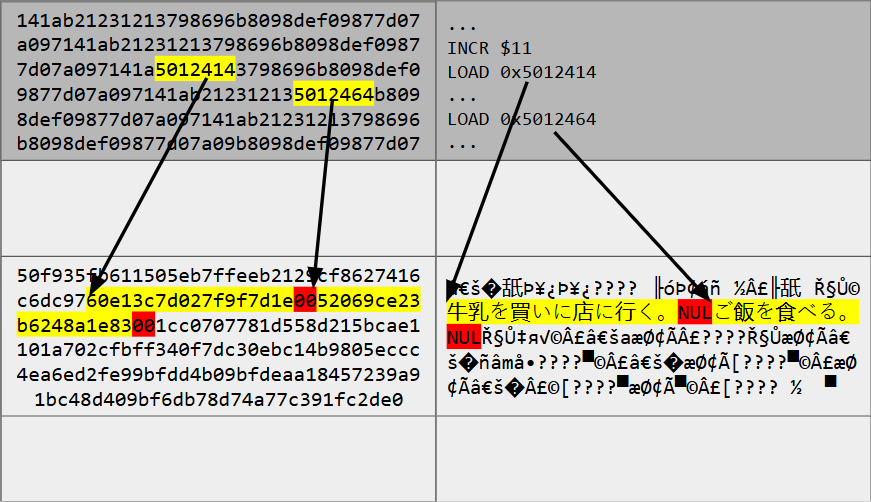

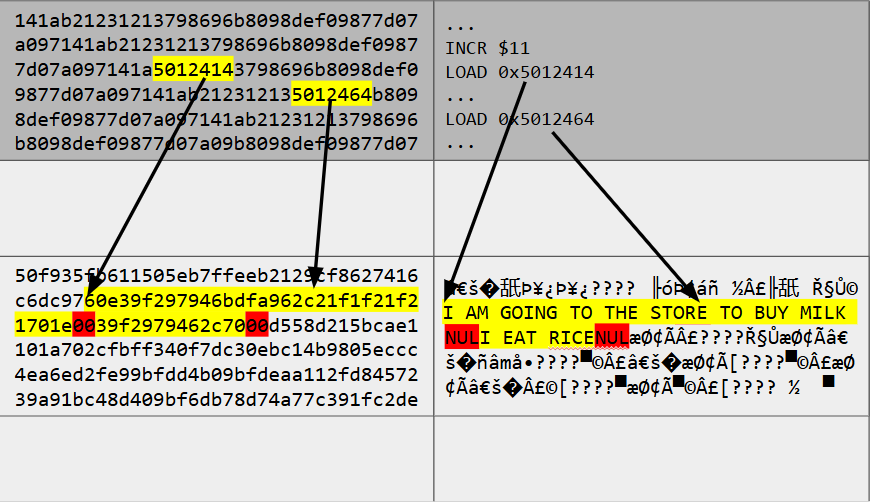

In [7]:
# An example of how overfilling strings cannot work without modifying the associated pointers

from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "An example of how overfilling strings cannot work without modifying the associated pointers."
            ]
        }
    }
}
display(Image("media/string_before.png"), metadata=metadata)
display(Image("media/string_after.png"), metadata=metadata)


Because of this, it is common to invoke a memory manager application which will reorganize the pointers in the code. In our example, we were able to use empty space at the end of the ROM file to be used to store our strings, as well as re-using the previously allocated memory from the japanese strings. This increases the flexibility of translators, but does not entirely eliminate it, for there remain two distinct constraints: The unallocated ROM size and the visual space given to the text. 

Expanding the ROM size is straightforward. The cartridge sizes for the GBA increment in powers of two (i.e. 4MB, 8MB, 16MB and 32MB). To expand to the next size, simply pad the end of the ROM to that boundary. The addressing space of the ROM is 0x08000000---0x09FFFFFF so 32MB is the practical limit of size for ROM translators and generally sufficient for that purpose. For more involved fan works which expand the scope of existing media, it is possible to implement software-controlled ROM paging to use a larger cartridge. Due to its complexity of implementation, this technique is not often used and of course, cannot fit on a standard physical retail cartridge. The vGBA-m recently added support for ROM sizes up to 128MB, but many others do not support such ROMs <cite id="gkdeu"><a href="#zotero%7C23690838%2F9YYDH3PY">(Team, 2025)</a></cite>.

In *Chobits*, much of the dialogue is in the same location throughout the game --- at the bottom of the screen. This area can fit up to 32 characters split over two rows. Even if we have the memory space to write a long and accurate translation, it may not fit in the text box and run off-screen. This area was restricted to the 2-byte SHIFT-JIS variant encoding mentioned before, so we unfortunately could not save space by using the smaller encoding. The difference in character width can be see in Figure \ref{fig:screen1} which also shows the dialogue text box. Sometimes dialogue will continue on a gamepad button press and a refresh of the textbox, but while other visual novel games implement this "page turn" by checking for a special reserved character in the encoding set, it seemed that each page of this game was programmed manually, so we worked within these limits for the sake of reduced complexity.

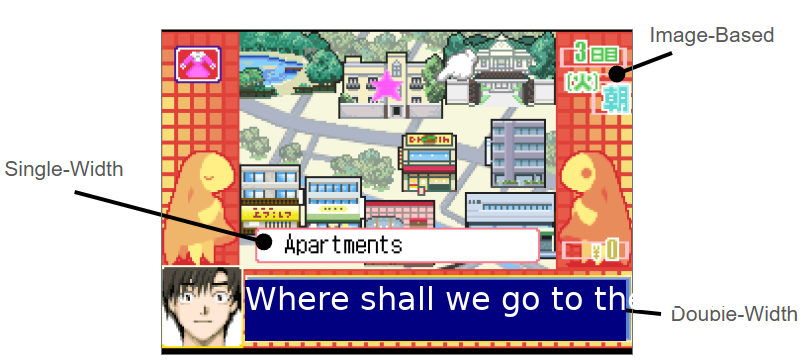

Fits: False


In [46]:
import os
from pathlib import Path

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

img_path = "media/text_types.png"


def load_overlay_font(size: int = 40):
    """Monospace / fixed-pitch TTF for column alignment; ``load_default()`` is bitmap (tiny)."""
    mono_families = [
        "DejaVu Sans Mono",
        "Liberation Mono",
        "Courier New",
        "Consolas",
        "Monaco",
        "Courier",
    ]
    try:
        from matplotlib import font_manager

        path = font_manager.findfont(
            font_manager.FontProperties(family=mono_families)
        )
        if path and Path(path).suffix.lower() in (".ttf", ".otf", ".ttc"):
            return ImageFont.truetype(path, size)
    except (ImportError, OSError):
        pass
    windir = os.environ.get("WINDIR")
    candidates = [
        *(Path(windir) / "Fonts" / n for n in ("cour.ttf", "COUR.TTF", "consola.ttf") if windir),
        Path("/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf"),
        Path("/usr/share/fonts/truetype/liberation/LiberationMono-Regular.ttf"),
        Path("/usr/share/fonts/TTF/DejaVuSansMono.ttf"),
    ]
    for p in candidates:
        try:
            if p and Path(p).is_file():
                return ImageFont.truetype(str(p), size)
        except OSError:
            continue
    try:
        return ImageFont.truetype("cour.ttf", size)
    except OSError:
        return ImageFont.load_default()


def wrap_fixed_chars(text: str, chars_per_line: int = 11) -> str:
    """Hard-wrap so each line has at most ``chars_per_line`` characters."""
    return "\n".join(text[i : i + chars_per_line] for i in range(0, len(text), chars_per_line))


def render_text_overlay(
    text,
    x=245,
    y=280,
    box_w=380,
    box_h=60,
    chars_per_line=11,
    font_size=32,
    pixel_scale=2,
):
    """Draw with a monospace font. ``pixel_scale`` > 1 draws smaller then NEAREST-upscales for a chunky look."""
    img = Image.open(img_path).convert("RGBA")
    draw = ImageDraw.Draw(img)

    wrapped = wrap_fixed_chars(text, chars_per_line)
    scale = max(1, int(pixel_scale))
    small = max(8, font_size // scale)
    font = load_overlay_font(small)

    scratch = Image.new("RGBA", (1, 1))
    scratch_draw = ImageDraw.Draw(scratch)
    bbox = scratch_draw.textbbox((0, 0), wrapped, font=font)
    ox, oy = bbox[0], bbox[1]
    tw = int(bbox[2] - bbox[0])
    th = int(bbox[3] - bbox[1])

    layer = Image.new("RGBA", (max(1, tw), max(1, th)), (0, 0, 0, 0))
    layer_draw = ImageDraw.Draw(layer)
    layer_draw.text((-ox, -oy), wrapped, fill="white", font=font)

    if scale > 1:
        layer = layer.resize(
            (layer.width * scale, layer.height * scale),
            resample=Image.NEAREST,
        )

    text_w, text_h = layer.size
    fits = text_w <= box_w and text_h <= box_h

    box_color = "navy"
    draw.rectangle([x, y, x + box_w, y + box_h], outline=box_color, fill=box_color, width=2)
    img.paste(layer, (x, y), layer)

    return img, fits


img, fits = render_text_overlay("Where shall we go to the next?")
display(img)
print("Fits:", fits)


Although these methods may alleviate the size limitations on the game's text content, It may be favourable for the overall experience of the game to trade accuracy in translations for visual cohesion. For example, if Figure \ref{fig:screen1}'s dialogue was translated more correctly as "Where shall we go?" this would be 18 characters, rather than 11 and there would need to be a line break placed somewhere within the sentence.

## Image Translation

As can be seen in Figure \ref{fig:screen1}, not all text in a game may be textual. (火) here is shorthand for 火曜日 or Tuesday, 朝 means "morning" and 日目 is "day". Rather than being found in our SHIFT-JIS or ASCII encodings, they are built from image sprites in the ROM memory and tiled onscreen. The main game dialogue, map and minigames were all translatable with text-based strings, and many fan translators would consider this enough to release the game. For a polished end product, these secondary display components, logos and title screens can elevate a game to a similar grade as a professional effort.

Similar to the encoding issue before, there are several formats that image data can take on the device, including compressed formats. The most common uncompressed representation of this image data is in multiple 8x8 pixel tiles with 4 and 8 bit indexes into a colour palette, stored seperately. The GBA BIOS provides a target-specific implementation of the LZ77 compression algorithm, as well as Huffman and Run-Length Encoding variants. Game developers may also implement their own compression schemes or encodings which are decompressed at run-time.

A selection of Chobit's tiles, with a randomized colour pallete, are shown in Figure \ref{fig:spritedump}, as seen from the YY-CHR tool (cite). As can be seen, some of the full sprites are disjoint in memory, sprites have various "widths" that differ to, or align with, the viewer's window size, causing some of them to horizontally "tear", some tiles also seem out-of-order. Both the diversity of image formats, as well as the various unique aspects of each sprite meant that extracting the sprites into an orderly folder of images was difficult. Instead, we extracted each candidate tile individually and used a script to stitch them together for editing. The image editing itself is not foolproof either --- compressed image data must compress to the same or greater amount in order to fit in the same memory location without overwriting adjacent data, the images seperate palletes can be difficult to trace and if modified, can cause unexpected colour alterations in other sprites using the same palette.

The main hurdle we encountered with the *Chobits* tiles however, is that, while we were able to discover many sprites in the ROM, many of the ones we wished to alter were not present. One particularly frustrating example was the "はい/いいえ" HUD icons for confirming and denying a choice (e.g. for choosing the player's name). While we can see similar looking tiles in Figure  \ref{fig:spritedump}'s bottom right corner, these tiles were not used for the segments of the game we tested. We were not able to discover the true location of this sprite, despite using techniques such as Corruption Mapping and using emulator's built-in runtime inspectors.

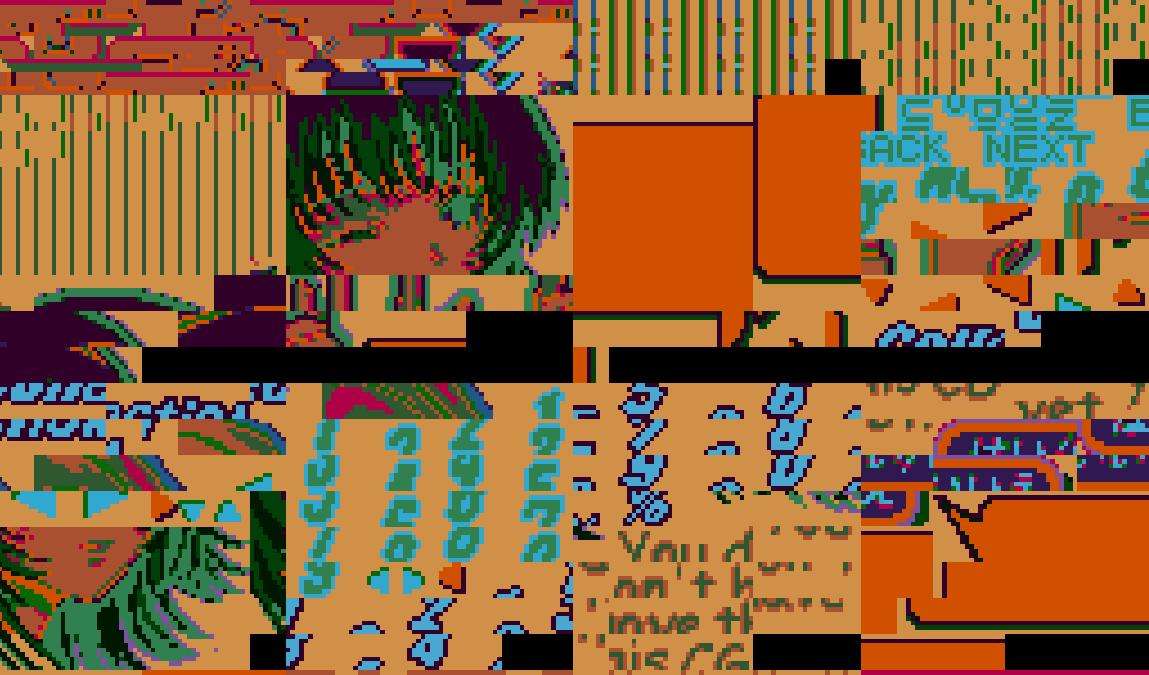

In [9]:
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "A section of the *Chobits* ROM with sprite data. Character, interfaces and textual images can be seen but much of it is out of order."
            ]
        }
    }
}
display(Image("media/chobits_spritedump.png"), metadata=metadata)


Corruption mapping or Pattern injection is a useful technique to locate the presence of elusive tiles (and other types of content). Simply, one corrupts a region of memory with a known value (e.g. 0xFF) and then visually inspects the effect the corruption has had on the game. For example, a tile may disappear, or audio might corrupt. It is important to do this with some knowledge of the broad "areas" in the ROM as corrupting a code section may cause unexpected behaviour including visual defects.

In lieu of this, we inspected another visual novel by the same production company --- ラブひなアドバンス 祝福の鐘はなるかな(often translated as "Love Hina Advance The Blessing Bell"), in which the image content was much more readily accessible. While much of the *Chobits* starting screens are video-based, the Love Hina game is sprite based and the large title display was much easier to visually locate than the small dialogue buttons. 

After locating the tile images, we performed the same extraction-modification-reinsertion procedure as before, and when we reloaded the game, the modified image appeared, as can be seen in Figure \ref{fig:logo_comparison}. Disregarding the author's artistic ability (or lack thereof) to replicate a title screen as impactfully as the original, the primary reason for the limited artistic expression of the display is due to the difficulty of aligning pixels between tiles, which had to be done via pixel counting. In some areas we were able to take larger "chunks" of the overall image at once, which made things simpler, but other areas had to be manually aligned. For a professional finish, it is likely that one would have to create a bespoke mapping and extraction suite to improve the freedom of the artist translating the tiles.

In [10]:
# TODO: be sure to be consistent about tiles vs sprites

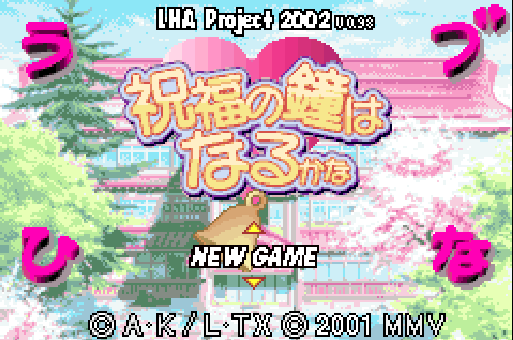

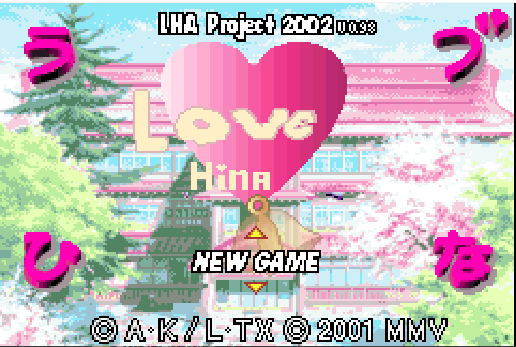

In [11]:
# IMAGE: Replacing the game title via sprite modification

from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Replacing the game title via sprite modification."
            ]
        }
    }
}
display(Image("media/love_hina_logo_original.png"), metadata=metadata)
display(Image("media/love_hina_logo_new.png"), metadata=metadata)



## Video/Audio Translation

Most fan translation efforts stop at text and image translation as this covers the majority of the content within these games. However, for completeness, we will comment briefly on these topics here.

Video was often performed with bespoke compression codecs, though later games often used the propeitary Mobiclip format by Actimagine. The complexity of decoding these is much higher than that of text or image data, and it also suffers from the compression problem mentioned earlier - where translating the media can inflate the file size, making it overflow the original allocations. The videos in *Chobits* and Love Hina appear to rapidly update the on-screen sprites with a range of predefined tiles, which appear in VRAM in a debugger to be simply noise or scrambled fragments\endnote{Part of the complication here is the added fact that sprites can be transparent, meaning that the images shown onscreen are often composites of several sprites.}, but when correctly indexed and streamed at the device frequency, they form a cohesive moving image. 

The retrieval of these tiles is an system that is highly opaque; without access to the original tools, code or documentation, the translation of these components is much higher than the payoff for their translation.

Similar to video, audio is technically difficult to reverse engineer and modify. The GBA lacks a dedicated audio synthesizer chip and instead operates with simple waveforms and pulse code modulation (PCM). Many games use the MP2000 Sound Engine (also known as "Sappy", "mp2k" and "m4a") and several tools exist to read, write and modify the tracks on the device (Such as Sappy 2006, shown in Figure \ref{fig:sappy}). However, changing the "instruments" or digital samples can require gathering knowledge of and experimenting with the available sounds within the game's sound tables.

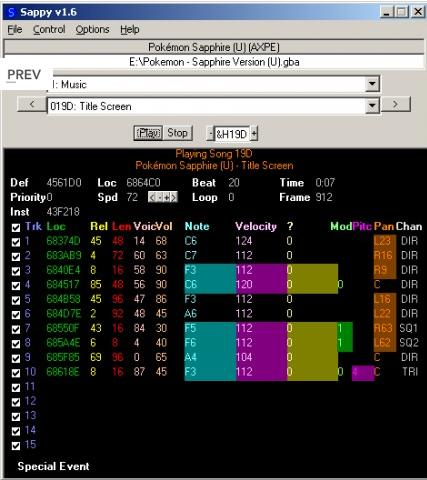

In [12]:
# TODO: Can we use chobits here?
from IPython.display import Image 
metadata={
    "jdh": {
        "module": "object",
        "object": {
            "type":"image",
            "source": [
                "Screenshot of an audio track during playback in Sappy 2006. It shows 10 audio tracks defined, their associated MIDI events, memory offsets and hardware channels."
            ]
        }
    }
}
display(Image("media/sappy.jpg"), metadata=metadata)

Seperate to the technical reasons for one to pass over the video and audio translation, there are also cultural preferences in the foreign consumers of Japanese media to have "Subs" instead of "Dubs". Even when Japanese media is officially translated with professional English voice actors, many enthusiasts will specifically seek out the original Japanese audio. Fans often cite reasons such as higher quality, faithfullness to the original script and the audio as it was originally envisioned. Regardless of their reasons, leaving the audio untouched can often satisfy the players who view this as an essential part of the game's atmosphere, whilst also sparing themselves the immense effort of both technically translating the audio and sourcing high quality voice talent. In an interview in 2025, CrunchyRoll (the largest anime-only streaming sevice) president Rahul Purini reports 48\% of U.K. anime fans watch anime subtitled. <cite id="bzzvc"><a href="#zotero%7C23690838%2F8ISK38P8">(Mullicane, 2025)</a></cite>

In [13]:
# read https://etd.ohiolink.edu/acprod/odb_etd/etd/r/1501/10?clear=10&p10_accession_num=dayton1524673372340251 and see if we should cite it.

## Code Decompilation \& Recompilation

Usually a fan translation of a GBA game would not require any changes to the machine's assembly code, but having the ability to change it can give further flexilbility to the translators. For example, the *Chobits* game text can be paged, only displaying a portion of text between the player pressing a button. This can either be due to long messages, or act similar to a page-break effect. This could be implemented in a dynamic way (e.g. creating a new page whenever a specific page-break character is read within a large string) or a static way (a hardcoded set of pages with seperate strings), as shown visually in Figure \ref{fig:paging_methods}. A static approach will constrain the translator to that static number of pages, wheras a dynamic approach will allow for more pages of text. 

However, decompiling the ARM7TDMI machine code into human-readable source-code is a complex process, and will not be able to regenerate elements of the original game source code that would assist in understanding it --- variable names, function names and comments. Moreover, high-level language construsts such as for, while loops, macro expansions can compile to functionally equivalent machine code. There may be hand-written assembly that was never part of a high level language, or optimizations implemented by the compiler that have unintuitive transforms. Decompilation can provide fanslators with a behaviourly equivalent of the original program, howevr this code may still require stubstancial manual interpretation to navigate.

The first step in retrieving the source code is to transform from the raw bytes contained within the ROM, to the ARM assemby instructions. The ARM7TDMI instruction set is well documented making the translation of instructions largely deterministic and straightforward. Greater difficulty lies in distinguishing code from the rest of the data within the ROM. While the ROM has a standardized declaration of the code entry point in its header, identifying additional code regions requires exploring the full natural execution of the code --- including following all conditional branches, function calls, interrupts and indirect jumps. The recursive traversal just described and other techniques are discussed at length in \ref{pang2020sokwantedknowx86x64}, and while this analysis focuses on x86/x64 platforms, many of the techniques apply equally to ARM devices such as the GBA. Indeed, some of the tools mentioned, such as Ghidra and Radare2 have been used by ROM Hackers to disassemble GBA ROMs.

In [14]:
# https://megabeets.net/blog/reverse-engineering-a-gameboy-rom-with-radare2/
# ARMv4T  is the instruction set, ARM7TDMI is the hardware. to clarify.

Some of these disassemblers also provide decompilation through a mixture of pattern and structural analysis. This will transform the generated assembly into a plausible high-level sourcecode (generally C). Many GBA games were cross-compiled with GCC for ARM distributed with the official SDK. Knowing this allows decompilers to exploit predicatable GCC idioms such as calling conventions, function prologues, stack frame layouts and general code generation patterns. 

As previously mentioned, function and variable names are not recoverable, meaning that the purpose of these structures still require their behaviour to be analyzed. Disassembly and decompilation tools typically assign autogenerated names through incrementing schemes independent of the game's logic (e.g. "func41", "var21"). These names provide no semantic information so investigation requires reasoning about the input, output, control flow and data acccess patterns of the program.

Fully decompiled and human-readable projects are rare and limited to the more popular titles for the console. These projects are generally focussed on enabling extra functionality, or entirely new unofficial games, rather than just translation.

### Data Integrity

Another reason to modify the code of the game is to circumvent data integrity checks.  While rarely used, the GBA ROM header includes a checksum byte which can be cross-checked to verify the integrity of the ROM, conditionally halt the game on a failure. This system is well known and several tools exist for ROM hackers, such as Checksuminator, to re-calculate the checksum and sometimes also replace it in the ROM. 

In [15]:
# https://www.romhacking.net/utilities/1696

Understandably, most ROM hacking development is performed on a PC using an emulator. Some titles embed hardware or timing probes to detect non-standard setups such as bootleg or flash cartridges and emulators. "Dragon Ball Z: The Legacy of Goku II" performs a series of reads from specific bus and I/O registersthat behave differently on flash cartridges, causing the game to fail. Unlike trivial header field replacements, these modifications can require meaningful modfiication of game code or data to allow the game to play as expected.

In the GBA era, anti-corruption techniques were relatively simple and rarely meaningfully obstructive, whereas modern consoles incorporate far more sophisticated methods for runtime integrity and piracy prevention, increasing the complexity of fan translation and modification. However, the game industry has grown such that multi-lingual releases are much more common practise. In <cite id="lb5ui"><a href="#zotero%7C23690838%2FZCAKKSTJ">(Dranch, 2019)</a></cite>, they provide details about the languages that the games from the top 1000 best-selling titles on the Steam platform have been released in. Almost all games have an English translation, followed by roughly 70\% of the FIGS languages (French, Italian, German, Spanish), significantly higher than the rates on the GBA as seen in Table \ref{tab:language-support} earlier in this paper. The article points out that the Asian markets are now potentially underserved at only approximately 30\% of games with translations available. Interestingly this is not too different from the GBA figures, but the market in China has significantly improved.

## Releasing

Fan translation projects are typically distributed as patch files that are intended to be applied to player's own game copies. These patch files use formats niche to the hobby such as the International Patch System (IPS) and UPS (Acronym expansion unknown) which was created to address limitations of the former system. They operate on binary files in a similar, but simpler, manner to the xdelta tool which is used for similar purposes outside the hobby.

*Chobits* had only one physical cartridge release, so a single patch file would be easy and sufficient to produce. However, for games with several releases (e.g. official translations, revisions, publisher changes, limited editions, etc), the offsets within the ROM may have changed, causing a patch file to corrupt these files. Therefore, fan translators must either produce multiple patch file releases, or standardize on a specific edition. As many changes to the ROM may not be automated, fan translators tend to favour the latter approach.

# Analysis

The emerging insight in this study is that there are many technical barriers for unofficial fan translations, beyond the typical linguistic complexities one might encounter translating other media. The GBA platform is an older system, and even with the advantage of being simpler technology and years of community development, many aspects remain tedious, manual and impenetrable.

## Practical Approaches

The main purpose of fan translation is to make media accessible to new audiences. With that in mind, certain aspects of a GBA game are more influential than others. We offer a broad cross-compare the "return on development" for several features in Table \ref{tmatrix}. Clearly, the main game text and dialogue is the heart of the visual novel and without it, the game cannot be played. There are two approaches, as discussed earlier in Section \label{section:text} --- in-place text translation, which, while easier, severely limits the translator to the original text size. The other approach, in which the game's pointers are changed to newly allocated memory locations, while harder, gives significantly more freedom to the translator. This difference could be the difference between the translation freedom of two alphanumeric characters, or thirty-two.

In our experience with the *Chobits* case study, this is likely enough for all but the toughest of translation scenarios. A translator may have to still use sub-par translations due to limited space, but it is enough to communicate the significant aspects of the text.

Many game UI components in the *Chobits* game were rendered as graphical assets. However, the function of these buttons, tabs, and other interactive components could generally be derived from either their visual appearance (e.g. different character sets for typing out a character name) or trial-and-error function (e.g. "Yes" which advances the game, "No" which returns the player to a previous screen). While functional, it is not an ideal gaming experience to have the player decypher and intuit parts of the game themselves, therefore adding translations for these components can be valuable. However, this does require additional skill, both artistic and technical, and the difficulty increases should the translator encounter a non-trivial encoding system for the images.

Other aspects of the translation process are often too cumbersome to implement unless a translator is particularly motivated, skilled and patient. Video and Audio replacement requires much more than simple data swapping. It requires videography and audiography skills, bit-rate re-encoding, timing reconciliation, compression knowledge to name some technical limits, not to mention voice acting talent. The technical process of decompilation of the codebase is possible with modern tooling, but interpretting the generated source is still a gargantuan effort. Realistically, the effort required is disproportionate to the payoff of simply longer translation strings. However, if a project aim is to add additional functionality to a game, above language replacement, this would be an essential requirement.

In [16]:
# TODO: Talk about variable width fonts. (e.g. i is thinner than W)

| Difficulty vs Impact | Low Impact | Medium Impact | High Impact |
|----------------------|------------|---------------|-------------|
| High Difficulty      | Video & Audio Replacement   | Dynamic Page Management | Reverse Engineering Propietary Compression |
| Medium Difficulty      | Graphical System Text (e.g. "Loading...")   | Graphical UI Components  | Memory/Pointer Table Reallocation |
| Low Difficulty      | ROM Header Data     | In-place String Replacement  |  -  |

While the table presented here is inherently subjective, it is presented as a guideline rather than a rule. Difficulty is judged based on required prior knowledge, current availability of tooling or documentation. The "Impact" axis is more aligned to the expected functional result on the translation. For example as was explained previously, textual content trumps audio/visual content for most titles. Logically, a project would gain most benefit starting with implementing features from the bottom-left and moving towards the top-right as development progresses.

## Pipeline Improvements

### Clean, Repeatable Builds

A risk for the inexperienced translator is to rely on incremental manual changes to the base ROM. A developer may overwrite critical data in a future "chapter" of the game, while only testing the first one. These silent bugs can remain hidden until late in development, causing significant reimplementation work. To mitigate this, it is advisable to have a repeatable pipeline of scripts and tool calls so that the ROM can be rebuilt from a "clean" state each time. If a bug is encountered later on, one can disable some of the steps in a triage attempt. This becomes more critical as a translation effort becomes more complex and changes to the ROM are less certain.

For instance, in our effort to translate the *Chobits* game, we created two scripts for text replacement. One to detect and extract game strings from the ROM into a csv file, and another to process an annotated version of that csv with our translation replacements. 

Depending on the complexity of the translation, development teams may feel that the overheads of creating a rigid pipeline may outweigh its benefits. For example, some ROM hacking tools allow in-place "drawing" over the tiled graphics, without exposing the artist to pallete indexing, non-contiguous memory or the commandline. It must also be considered that some who enter the real of ROM hacking are not programmers and interact with the hobby through community provided tools only.

### Testing

In [17]:
# Do we mention debuggers enough in the main paper?

In most software projects, testing is a standard practice. However, the options for ROM hackers are limited. While decompiled or original games can take advantage of existing C testing suites such as GoogleTest <cite id="dpkr5"><a href="#zotero%7C23690838%2FCST74MPW">(Google, 2026)</a></cite> or create their own, translators operating solely on the compiled ROM have fewer facilities. 

Emulators often provide a facility for saving full-system snapshots --- copies of the system's volatile memory (RAM, VRAM, registers) at a precise moment in time --- allowing translators to immediately "jump" to specific scenes or scenarios within the game ROM (e.g. the start of each chapter). This allows more granular "jumping" than traditional game saving provided by the cartridge itself. This is immensely useful for the hobbyist translator for saving time to verify their translations have loaded in correctly, but it must be mentioned that it is not infallible --- because the save state preserves the exact memory conditions of the moment it was created, it can mask issues that only occur during a contiguous play session, such as memory leaks or pointer corruption. It also does not verify that the state itself is reachable naturally by the preceding code should it be later edited.

Other than manual validation, some emulators like mgba <cite id="56hhc"><a href="#zotero%7C23690838%2F5WE9PFH3">(Pfau, 2013)</a></cite> offer scripting APIs that facilitate memory inspection and automated gamepad input. This may be useful for confirming that translations have been written correctly to the ROM, but despite the helpful APIs, for many cases it may be easier to perform static test externally than dynamically through the API --- for example, validating all strings are of a certain length before writing them to ROM, than to inspect a specific location in VRAM for overflow. That being said, the game strings in *Chobits* are generally complete and do not include variable injection (e.g. where "You found a \[ITEM\]" is expanded during execution and the string length is not known ahead of time), which may be better suited to a dynamic testing approach.

Ultimately, while sophisticated dynamic analysis is available, the fact that most information is either known ahead of time, or can be investigated beforehand means that validation of the modification scripts, their inputs and their outputs, is a more practical approach barring particularly complex transformations.

### Abstraction

While translators may be motivated to the hobby by their interest in a particular game title, generic community tools are of large benefit to the hobby as a whole, and contributions back into this sphere should be encouraged. Many titles require the same type of operations, just the data is different. The game "Love Hina", as mentioned in Section \ref{sec:graphics}, is a visual novel by the same development company as *Chobits* and many required operations for data extraction and replacement would surely be common between them. 

It has also been mentioned that translating GBA games is a hobby which requires many different skills.  Abstracting data into common formats, such as CSV or XLSX can make it easier to recruit translators to assist with the project as they are more likely to be familiar with spreadsheets than with command-line interfaces. It also opens new sources of assistance, for example with crowd-sourced websites such as OneSky <cite id="ciiy5"><a href="#zotero%7C23690838%2FEN4PSJM3">(OneSky, 2026)</a></cite>, or machine translation through the use of large language models (LLMs). Furthermore, adopting a internationalization standards --- such as  those defined by the W3C's (i18n) <cite id="0gyrf"><a href="#zotero%7C23690838%2FI5JF8AEM">(W3C, 2026)</a></cite>, projects can facilitate other translators to add their own language contributions with limited technical knowledge. Thus, a single technical effort can enable localizations in multiple target languages simultaneously, even if not with immediate effect. This lack of coordination seems to be the single largest barrier to the goal of the fanslator - to provide media access to those who cannot access it.

During the course of this project, a machine-translated fanslation of *Chobits* was released (unaffiliated with this work or its authors) <cite id="n7jde"><a href="#zotero%7C23690838%2FXVQ56289">(Gopicolo, 2025)</a></cite>. While this release's quality of translation is middling to poor due to lack of contextual information, it does show how such technologies can provide a quick initial implementation in which human refinement can be built on top of.

### Alternative Solution - Real-Time Screen Translation

In addition to ROM modification, recent advancements in Optical Character Recognition (OCR) and Computer Vision have introduce "on-the-fly" translation solutions as a low-barrier alternative. The RetroArch <cite id="6b7tr"><a href="#zotero%7C23690838%2FBFJRLXGQ">(Libretro Team, 2024)</a></cite> platform can capture a game's frame buffer, extract the text, process it through a machine-learning system and overlay the resultant translated text atop the game.

While these tools offer immediate translation, they suffer from the same contextual isolation issues that a blind machine-translation of a game's script would, as well as the OCR technology as a possible additional source of errors. However, recent benchmarks of OCR accuracy  have undergone significant iterative improvement and suggest that the gap between manually patched games and automated overlays may narrow, though lack of access to the internal state of the game (for example, understanding that "Cloud" is a character name and not an object) remains a limitation.

In [18]:
# Can we do an example here?

# Conclusion

In this paper, we've detailed the development of a fan translation of the Game Boy Advance title *Chobits: Atashi Dake no Hito*. With limited existing academic research on the technical aspects of fan translation, this paper provides a deep overview of the challenges that these hobbyists face and the approaches they take against them. 

Through our case study, we show the multi-layered and complex nature of translating such a game. Requiring hobbyists to possess technical, linguistic and artistic skills of various depth. We show the raw text translation techniques required to perform a basic, functional localized version of the game, but discuss the process and feasibilities of more deeply integrated translations such as image-based changes. Code modifications, audio and video modifications are typically poor returns of time investment unless such a feature is critical to a project.

The case study was not without challenges. We were unable to disern the encoding of certain key UI assets within the game and had to examine another game (Love Hina Advance) to demonstrate the concept, demonstrating that even though guidelines can be given, ultimately the game cartridge is a compiled artefact with little insight on its original sourcecode state or implementation designs. It is upon the back of many community guides, tools and insights that such a hobby can exist.

Along with our study, we provide a set of practical recommendations for those undergoing similar efforts. In particular, we encourage the use of clean, reproducible pipelines over incremental manual modifications to avoid silent data corruption. We advise on the practical aspects to focus development on, and which to avoid. We also advocate the further abstraction of the tools and processes used in fan translation --- opening the hobby to more languages and contributors to further the goal of making the games accessible to new fans.

## Ethics

As has been described in the [Introduction](#introduction), this research focuses exclusively on the methodology of reverse engineering and translation techniques for the GBA of which knowledge is transferrable to other games and other platforms. 

Therefore, the artefacts of this research have not been published as a traditional fan translation may have been. The author is neither trained in the field of translation, nor do they wish to extend this work beyond the bounds of academic research. No software patches, modified binaries or extracted game assets have been made available to the public from this work.

This approach ensures that the primary contribution of this paper is to the field of software engineering, while strictly respecting the intellectual property and copyright boundaries of the original rightsholders.

## Future Work

While the specific development and publicaiton of the *Chobits* translation will not be resumed, the scripts and frameworks used throughout this project provide a foundation for the construction of community tooling. One potential area for investigation is increasing the effectiveness of LLMs to automate game translations by programmatically providing required context and localization advice.

Infrastructural improvements would be a welcome addition. In particular, testing, as cycle time for a project can be slow due to the repeated manual checking of temporal string placement and visual defects. Further efforts in enabling others in their localization efforts through internationalization frameworks and modular extraction/replacement tools are essential for modernizing the field.

Overall, fan translations have been neglected in technical research, despite the inherently interesting space it occupies --- a place on the fringes of legality, driven by a hacking culture and outside mainstream tooling and formal structures. We hope this study will inspire others to perform similar analyses.

TODOS:

- The ``difficulty vs. impact'' table is a helpful heuristic but should be tied to observed results (e.g., which operations actually bottlenecked work time, typical iteration counts, or failure rates).

- While the topic differs from the included related work summaries, the paper could learn from pipeline-oriented approaches (e.g., KGpipe, AutoStreamPipe) by emphasizing modular, reproducible, and evaluable steps—particularly around extraction, transformation, and validation stages. Likewise, the attention to reproducibility and cost-effectiveness in CEBench aligns with the paper's emphasis on clean builds and testing, suggesting a more formalized, scripted build harness and test matrix could be documented.

- The broader ROM-hacking and preservation literature (beyond Sánchez 2009; Barnabé 2018; Kirtz 2018) is under-cited. Foundational game localization works (e.g., O'Hagan \& Mangiron's ``Game Localization'') and preservation/archiving scholarship (e.g., Lowood, Newman, McDonough) would deepen the cultural, ethical, and infrastructural framing and connect the technical practices to DiGRA's core concerns.

- The ethics section's decision not to release assets is defensible, but the paper should still aim to release non-infringing artifacts (e.g., scripts, table-file templates, synthetic ROM stubs, addresses and offsets without copyrighted data) to enable replication. This is crucial for academic impact.

- The exploration of LLM/OCR-based real-time overlays is forward-looking; however, their limitations (contextual ambiguity, OCR errors, lack of internal state) should be grounded in small empirical demos (e.g., show failure cases with homographs, character names, or system text) to avoid overpromising.

- Can you quantify your text extraction coverage for Chobits (e.g., number of candidate strings found, proportion confirmed as dialogue/system text, number of pointers successfully relocated, and any false positives/negatives)?

- You mention ''two encodings'' (half-width and full-width SHIFT-JIS). Do you mean a single SHIFT-JIS encoding rendered with two font widths, or two distinct in-ROM codepoint mappings? Please provide an excerpt of the table file or mapping that evidences the ''relocated roman characters'' claim.

- For Table 1 (IGDB language distribution), how were titles deduplicated across regions/editions, and how did you compute percentages for multi-language games? Please clarify methodology so the figures are interpretable and reproducible.

- Regarding the missing Chobits UI sprites (e.g., はい/いいえ), which compression formats and search strategies did you attempt (LZ77 signatures, Huffman tables, known custom schemes)? Did you trace VRAM DMA patterns or run-time palette changes to narrow candidates?

- Could you release non-infringing artifacts (scripts, pointer-reallocation utility, table-file templates, addresses/offset lists) to support replication while respecting IP constraints?

- Did you test ROM expansion and pointer relocation on real hardware or multiple emulators (mGBA, VBA-M, hardware via flash cart)? If so, were there timing or integrity issues, and how broadly compatible was the modified ROM?

- Can you provide a small, concrete example of moving a multi-page line from static to dynamic pagination (or vice versa) in Chobits, including the control markers or code hooks used?

- The ``difficulty vs. impact'' table is valuable; can you ground it with empirical time-on-task or iteration counts for each task class from your case study?

- Several legal claims (e.g., about reverse engineering acceptability and anti-circumvention) are context-sensitive. Could you refine the legal framing with more balanced sources and clarify jurisdictional assumptions?

- The OCR/LLM overlay discussion would benefit from a brief pilot comparison (patched vs. overlay) on a controlled set of scenes. Can you include a small ablation or error audit?

